# Feature Table Check

**Phase 4 companion notebook.** `pipeline/features.py` is a plain script — running it prints
a shape summary and writes a parquet file, but shows you nothing about whether the table
actually looks right. This notebook is the visual/interactive check: load the saved output,
eyeball it, and confirm the engineered features carry the signal they were designed for
(the same correlation numbers reported in the project report, Section 3.3).

Re-run this any time `features.py` changes, before moving on to modeling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 200)
plt.rcParams["figure.figsize"] = (9, 6)

# A notebook's working directory depends on how/where it's launched from -
# this bit us once already with features.py's original hardcoded relative
# path. Rather than assume, we check the plausible locations (cwd itself, or
# cwd/pipeline if this is being run from the repo root) and use whichever
# actually has the file.
CANDIDATE_ROOTS = [Path("."), Path("pipeline"), Path("..")]


def resolve(relative_path: str) -> Path:
    for root in CANDIDATE_ROOTS:
        candidate = root / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Couldn't find {relative_path} from any of {CANDIDATE_ROOTS} "
        f"(cwd={Path.cwd()}) - check where this notebook's kernel is running from."
    )


FEATURES_PATH = resolve("data/processed/features.parquet")
RAW_APP_PATH = resolve("data/raw/application_train.csv")
print("Loading features from:", FEATURES_PATH.resolve())

Loading features from: C:\Users\nguye\credit-risk\pipeline\data\processed\features.parquet


## 1. Shape and a first look

Confirms the row count didn't change (it shouldn't — every join in `features.py` is a
left-join against one-row-per-applicant tables, so no applicant should be gained, lost,
or duplicated) and shows how many columns the feature-engineering step actually added.

In [2]:
df = pd.read_parquet(FEATURES_PATH)
raw_cols = pd.read_csv(RAW_APP_PATH, nrows=0).columns
new_cols = [c for c in df.columns if c not in raw_cols]

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Raw application_train columns: {len(raw_cols)}")
print(f"Engineered/aggregated columns added: {len(new_cols)}")
df.head()

Shape: 307,511 rows x 174 columns
Raw application_train columns: 122
Engineered/aggregated columns added: 52


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,IS_DAYS_EMPLOYED_ANOMALY,AGE_YEARS,EMPLOYED_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO,INCOME_PER_FAMILY_MEMBER,EXT_SOURCE_MEAN,EXT_SOURCE_STD,EXT_SOURCE_COUNT_AVAILABLE,BUREAU_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MEAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX,BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_ACTIVE_RATIO,BUREAU_DEBT_CREDIT_RATIO,HAS_BUREAU_HISTORY,PREV_COUNT,PREV_APPROVED_COUNT,PREV_REFUSED_COUNT,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_MAX,PREV_AMT_CREDIT_MEAN,PREV_AMT_CREDIT_MAX,PREV_APPLICATION_CREDIT_RATIO_MEAN,PREV_DAYS_DECISION_MEAN,PREV_DAYS_DECISION_MAX,PREV_CNT_PAYMENT_MEAN,PREV_APPROVAL_RATE,PREV_REFUSAL_RATE,CC_MONTHS_COUNT,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_UTILIZATION_MEAN,CC_UTILIZATION_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_MAX,CC_LATE_PAYMENT_COUNT,CC_AMT_DRAWINGS_CURRENT_MEAN,CC_CNT_DRAWINGS_CURRENT_MEAN,CC_LATE_PAYMENT_RATE
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637.0,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.01

## 2. Do the engineered columns look sane?

Two things to check here, not just "does it run": missingness rates should match what
the aggregation logic implies (e.g. `HAS_BUREAU_HISTORY`-related counts should only be
missing for applicants absent from that table), and there should be **zero infinite
values** — `features.py` had two divide-by-zero bugs that produced `inf` instead of a
real ratio, both fixed by treating a zero denominator as "undefined" (`NaN`). This cell
is the regression check for that class of bug if the aggregation logic changes later.

In [3]:
summary = df[new_cols].describe().T
summary["missing_pct"] = (df[new_cols].isnull().mean() * 100).round(1)
print(summary.round(3))

inf_counts = np.isinf(df[new_cols].select_dtypes(include=[np.number])).sum()
bad = inf_counts[inf_counts > 0]
print("\nColumns with infinite values (should be empty):")
print(bad if len(bad) else "none")

                                       count         mean          std  \
IS_DAYS_EMPLOYED_ANOMALY            307511.0        0.180        0.384   
AGE_YEARS                           307511.0       43.907       11.948   
EMPLOYED_YEARS                      252137.0        6.527        6.402   
CREDIT_INCOME_RATIO                 307511.0        3.958        2.690   
ANNUITY_INCOME_RATIO                307499.0        0.181        0.095   
CREDIT_ANNUITY_RATIO                307499.0       21.612        7.824   
INCOME_PER_FAMILY_MEMBER            307509.0    93105.880   101373.363   
EXT_SOURCE_MEAN                     307339.0        0.509        0.150   
EXT_SOURCE_STD                      270602.0        0.151        0.100   
EXT_SOURCE_COUNT_AVAILABLE          307511.0        2.236        0.650   
BUREAU_COUNT                        307511.0        4.765        4.496   
BUREAU_ACTIVE_COUNT                 307511.0        1.762        1.805   
BUREAU_DAYS_CREDIT_MIN              26

## 3. Correlation with TARGET — does the feature engineering earn its keep?

This is the same check behind the numbers in the project report (Section 3.3), as a
chart instead of a table since there are 52 columns to scan. Red bars are features where
a *higher* value means *more* risk (e.g. utilization, refusal rate); blue bars are the
opposite (e.g. age, external score). If a bar's direction doesn't match domain intuition
for that feature, that's worth investigating before trusting it in modeling — it usually
means the aggregation logic has a sign or scope bug, not that the model will "figure it
out anyway".

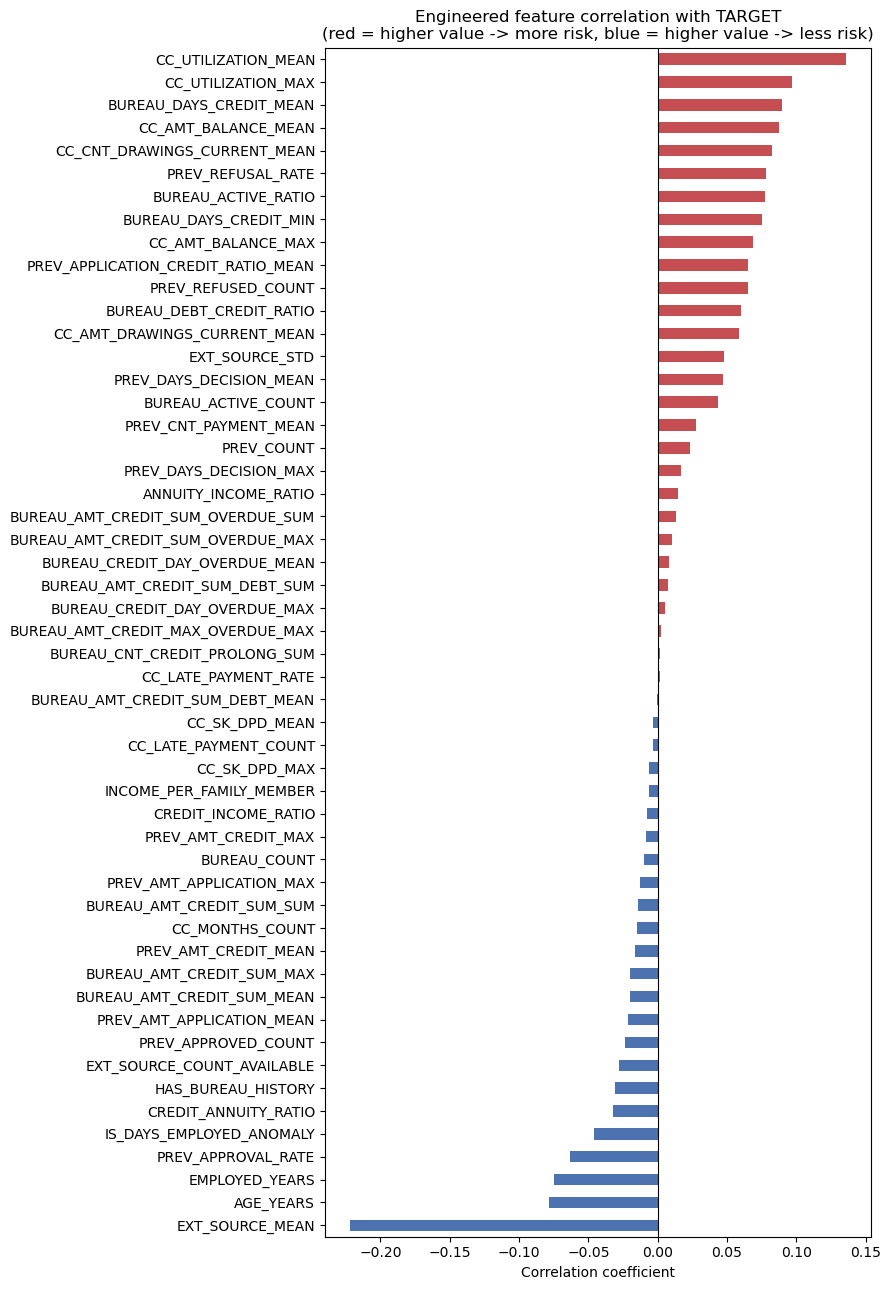

Top 5 strongest correlations (either direction):
EXT_SOURCE_MEAN           -0.222052
CC_UTILIZATION_MEAN        0.135560
CC_UTILIZATION_MAX         0.097011
BUREAU_DAYS_CREDIT_MEAN    0.089729
CC_AMT_BALANCE_MEAN        0.087177
Name: TARGET, dtype: float64


In [4]:
corr = df[new_cols + ["TARGET"]].corr(numeric_only=True)["TARGET"].drop("TARGET").sort_values()

fig, ax = plt.subplots(figsize=(9, 13))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in corr.values]
corr.plot(kind="barh", ax=ax, color=colors)
ax.set_title(
    "Engineered feature correlation with TARGET\n"
    "(red = higher value -> more risk, blue = higher value -> less risk)"
)
ax.set_xlabel("Correlation coefficient")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("Top 5 strongest correlations (either direction):")
print(corr.reindex(corr.abs().sort_values(ascending=False).index).head(5))

## 4. Did `EXT_SOURCE_MEAN` actually beat the raw `EXT_SOURCE` columns?

This was the headline claim in Report Section 3.3 — that averaging whichever of
`EXT_SOURCE_1/2/3` are actually present for an applicant produces a *stronger* predictor
than any single raw column. Checking that claim directly, rather than trusting the report
to still be accurate if the code changes later.

In [5]:
ext_compare_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "EXT_SOURCE_MEAN"]
ext_compare = df[ext_compare_cols + ["TARGET"]].corr()["TARGET"].drop("TARGET")
print(ext_compare.reindex(ext_compare.abs().sort_values(ascending=False).index))

EXT_SOURCE_MEAN   -0.222052
EXT_SOURCE_3      -0.178919
EXT_SOURCE_2      -0.160472
EXT_SOURCE_1      -0.155317
Name: TARGET, dtype: float64


## How to use this notebook going forward

Re-run top to bottom whenever `features.py` changes. Section 2 should always show **zero**
infinite-value columns — if it doesn't, a new ratio feature needs the same zero-denominator
handling as `BUREAU_DEBT_CREDIT_RATIO`/`APPLICATION_CREDIT_RATIO`. If the correlation numbers
in Sections 3–4 no longer match what's written in the project report's Section 3.3, treat the
report as the stale one and update it to match this notebook's live output, not the other way
around.